# Oscillograms

Probability across zenith angle and energy at once -- the two-dimensional map of what an atmospheric-neutrino detector sees.

This is the workload that most rewards passing arrays rather than looping: the energies share a chord, so the matter profile is built once.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

## Oscillograms

An oscillogram is the natural way to look at oscillations through the Earth:
the probability as a function of both the arrival direction and the energy, on
one map. The direction matters because it fixes the chord -- and therefore not
just the baseline but *which layers* the neutrino crosses. Everything
interesting in these figures comes from that.

The band structure running diagonally is ordinary vacuum oscillation: fixed
phase $\Delta m^2 L / 2E$ means the fringes follow lines of constant $L/E$.
What breaks that pattern is matter. Watch for the sharp feature near
$\cos\theta_z \approx -0.83$: that is the core-mantle boundary, where PREM's
density jumps by roughly a factor of two, and trajectories steeper than it
sample a genuinely different profile.

Below we define a helper that computes an oscillogram and draws it. The
drawing is a single call to `magnus.plotting.plot_oscillogram`; the colour
map, the colour-bar label, the tick spacings, and the white-stroked corner
annotation (which has to stay legible against a `plasma` background) are its
defaults.

In [2]:
def make_oscillogram_plot(nu_i, nu_f, H_func, costhz_arr, log10_Enu_arr,
                          n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3,
                          n_jobs=10, integration_method='trapezoid',
                          validate_input=False, sector_2nu=None,
                          cbar_label_pre='', save_plot=False, path=None,
                          filename=None, format=None):
    """Compute an oscillogram over (cos theta_z, log10 E) and plot it.

    Only the computation lives here now; the drawing is one call to
    magnus.plotting.plot_oscillogram, which carries the house style.
    """
    # For 2nu oscillations in the 23 sector the flavour indices have to be
    # remapped onto the 2x2 block the Hamiltonian actually spans.
    if sector_2nu == '23':
        nu_i_ = 0 if nu_i == gd.NUMU else 1
        nu_f_ = 0 if nu_f == gd.NUMU else 1
    else:
        nu_i_, nu_f_ = nu_i, nu_f

    # prob_arr[i][j] is the requested probability at Enu_arr[i], costhz_arr[j]
    prob_arr = np.array([[oscprob.osc_prob(
                              lambda l: H_func(costhz_arr[j], l, Enu_arr[i]*gd.UNIT_GEV),
                              0, l_max_arr[j]*gd.CONV_KM_TO_INV_EV,
                              n_slabs=n_slabs, n_tpts_per_slab=n_tpts_per_slab,
                              magnus_exp_order=magnus_exp_order, n_jobs=n_jobs,
                              validate_input=validate_input)[nu_i_][nu_f_]
                          for j in range(costhz_npts)]
                         for i in range(Enu_npts)])

    sector_label = {'23': r' (23 sector)', '12': r' (12 sector)'}.get(sector_2nu, '')

    fig, ax = plotting.plot_oscillogram(
        costhz_arr, log10_Enu_arr, prob_arr,
        nu_i=nu_i, nu_f=nu_f,
        cbar_label=cbar_label_pre + plotting.prob_label(nu_i, nu_f),
        annotation=plotting.prob_label(nu_i, nu_f) + sector_label,
        xlim=(costhz_min, costhz_max),
        ylim=(log10_Enu_min, log10_Enu_max),
        savefig=(path + filename + '.' + format) if save_plot else None,
        savefig_kw=dict(bbox_inches='tight'))

    return prob_arr

Define the ranges of zenith angle (and, therefore, baseline) and neutrino energies

In [3]:
# Cosines of zenith angles
costhz_min, costhz_max, costhz_npts = -1.0, 0, 150 #100 
costhz_arr = np.linspace(costhz_min, costhz_max, costhz_npts) 

# Baselines, L [km]
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] 

# Neutrino energies [GeV]
log10_Enu_min, log10_Enu_max, Enu_npts = 0.0, 1.0, 150 #100
Enu_arr = np.logspace(log10_Enu_min, log10_Enu_max, Enu_npts)
log10_Enu_arr = np.log10(Enu_arr)

Define the coherent forward potential inside the Earth according to the PREM matter density model.

Because of numerical errors, sometimes `r` can be slightly larger han the Earth's radius, `gd.EARTH_RADIUS`.  The parameter `tol` defines how much larger than 1 the quantity `r-gd.EARTH_RADIUS` can be inside the `earth.density_matter_func_prem`function.  We have set `tol = 1.e-15` manually below because it leads to successful results in our runs, but the user is advised to change its value if their code fails.

In [4]:
# r is the radius from the center of the Earth [km].  

def density_matter_func_prem_wrapper(r):
    return earth.density_matter_func_prem(r, tol=1.e-15)
    
def VCC_func_prem(r):
    return matter.VCC_func(r, lambda rr : matter.num_density_e_func(rr, density_matter_func_prem_wrapper, 
                                                                    ratio_number_neutrons_to_protons=1.0, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True)) # [eV]

Generate and plot the $2\nu$ oscillograms.  Let's consider the 2-3 sector, which describes mixing between $\nu_\mu$ and $\nu_\tau$. First, we define the Hamiltonians:

In [5]:
# # Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S23_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_2nu_23_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # [eV^2]

# Matter Hamiltonian
def H_2nu_23_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_2nu_23_energy_indep + hamiltonians.hamiltonian_2nu_matter(VCC_func_prem(r)) # [eV]

Now plot the oscillogram; the probabilities are computed inside the `make_oscillogram_plot` function:

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

array([[0.60738981, 0.87226446, 0.99741693, ..., 0.73254527, 0.92793908,
        1.        ],
       [0.99200377, 0.95024215, 0.73923228, ..., 0.73988974, 0.93007949,
        1.        ],
       [0.76857275, 0.47986524, 0.19792665, ..., 0.74705657, 0.93215789,
        1.        ],
       ...,
       [0.41364465, 0.33848141, 0.32460496, ..., 0.99686055, 0.99921449,
        1.        ],
       [0.41416282, 0.34147272, 0.33687104, ..., 0.99695601, 0.99923839,
        1.        ],
       [0.4156662 , 0.34897302, 0.34958474, ..., 0.99704856, 0.99926156,
        1.        ]])

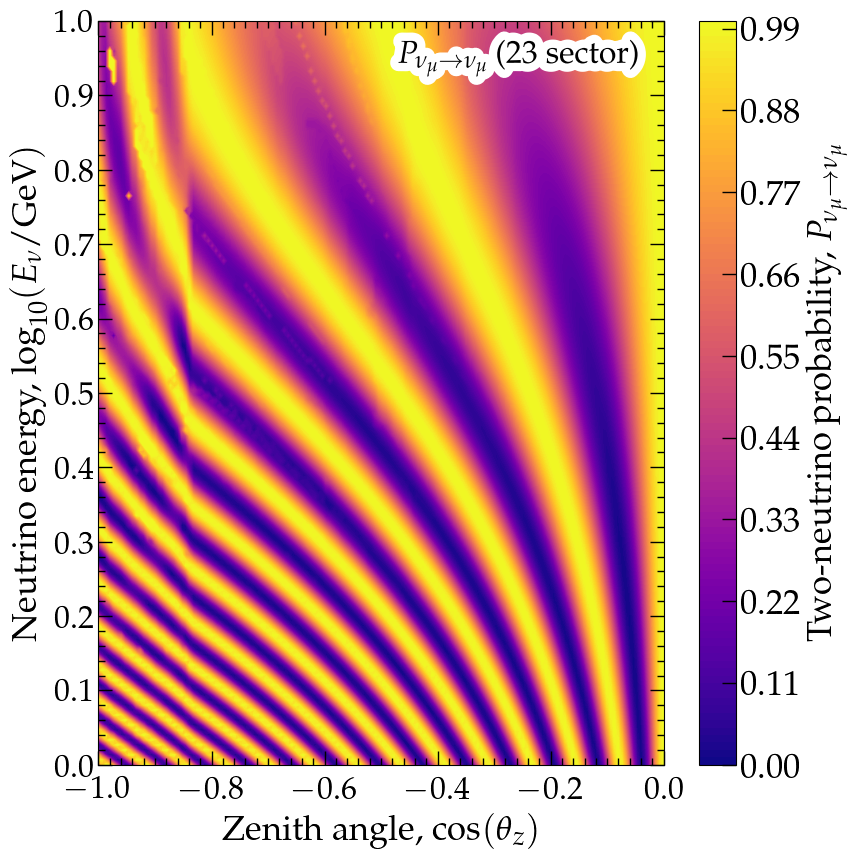

In [6]:
make_oscillogram_plot(gd.NUMU, gd.NUMU, H_2nu_23_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=1, n_tpts_per_slab=100, magnus_exp_order=1, n_jobs=1, integration_method='trapezoid', validate_input=False,
                      sector_2nu='23', cbar_label_pre=r'Two-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

The effect of the core-mantle transition in the density is clearly visible around $\cos \theta_z = -0.85$, as expected.

Of note, in the $2\nu$ case we already obtain the oscillograms that we expected by using a single slab (`n_slabs = 1`) and the lowest order of the Magnus expansion (`magnus_exp_order = 1`), which is equivalent to assuming a time-independent Hamiltonian, or an average matter density along each chord inside the Earth.

Now we can do the same for the 1-2 sector, starting with defining a new Hamiltonian with the mixing parameters of that sector:

In [7]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_2nu_12_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # [eV^2]

# Matter Hamiltonian
def H_2nu_12_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_2nu_12_energy_indep + hamiltonians.hamiltonian_2nu_matter(VCC_func_prem(r)) # [eV]

And then plot:

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

array([[0.93264221, 0.94952987, 0.96886461, ..., 0.99977546, 0.99994386,
        1.        ],
       [0.93440472, 0.95071875, 0.96947364, ..., 0.99978229, 0.99994557,
        1.        ],
       [0.93612828, 0.95188692, 0.97007749, ..., 0.99978892, 0.99994722,
        1.        ],
       ...,
       [0.99994219, 0.99989174, 0.99982806, ..., 0.99999761, 0.9999994 ,
        1.        ],
       [0.99994418, 0.99989536, 0.99983369, ..., 0.99999768, 0.99999942,
        1.        ],
       [0.9999461 , 0.99989884, 0.99983914, ..., 0.99999775, 0.99999944,
        1.        ]])

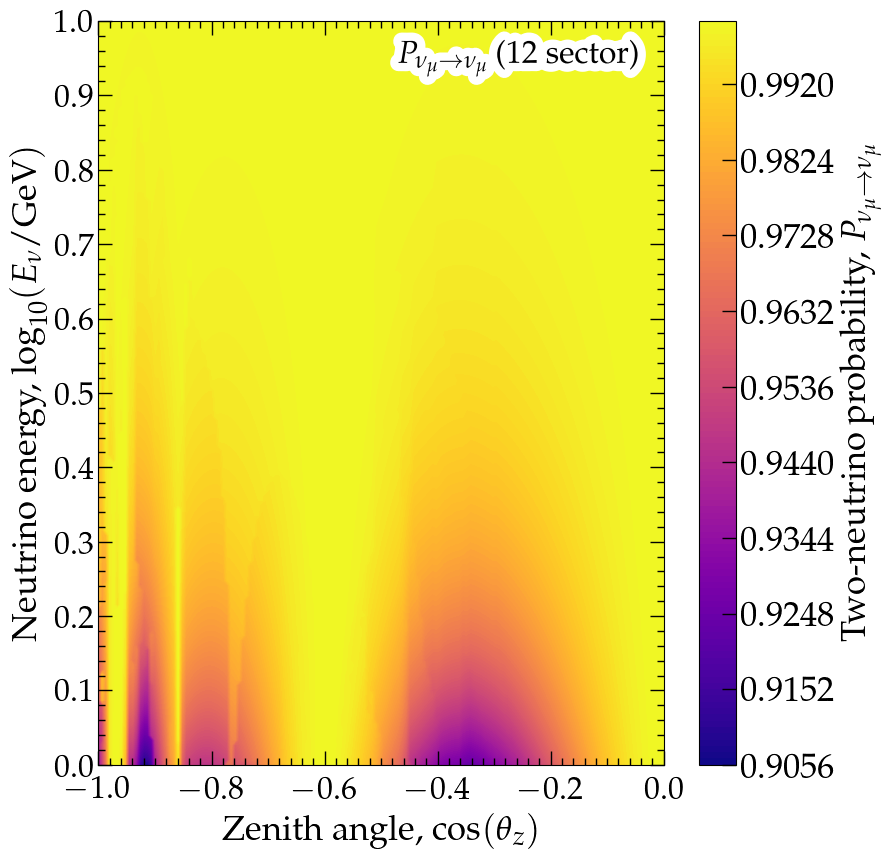

In [8]:
make_oscillogram_plot(gd.NUMU, gd.NUMU, H_2nu_12_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=1, n_tpts_per_slab=100, magnus_exp_order=1, n_jobs=1, integration_method='trapezoid', validate_input=False,
                      sector_2nu='12', cbar_label_pre=r'Two-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

Finally, let's do the same for $3\nu$ oscillations.  First, define the Hamiltonians:

In [9]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_3nu_energy_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31) # [eV^2]

# Matter Hamiltonian
def H_3nu_func_prem(costhz, l, energy):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_3nu_energy_indep + hamiltonians.hamiltonian_3nu_matter(VCC_func_prem(r)) # [eV]

And then plot:

In [10]:
def density_matter_func_prem_wrapper(r):
    return earth.density_matter_func_prem(r, tol=1.e-15)
    
def VCC_func_prem(r):
    return matter.VCC_func(r, lambda rr : matter.num_density_e_func(rr, density_matter_func_prem_wrapper, 
                                                                    ratio_number_neutrons_to_protons=1.0, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True)) # [eV]

Let's first generate the oscillogram for the same simplest settings that we used in the $2\nu$ case (`n_slabs = 1`) and (`magnus_exp_order = 1`).

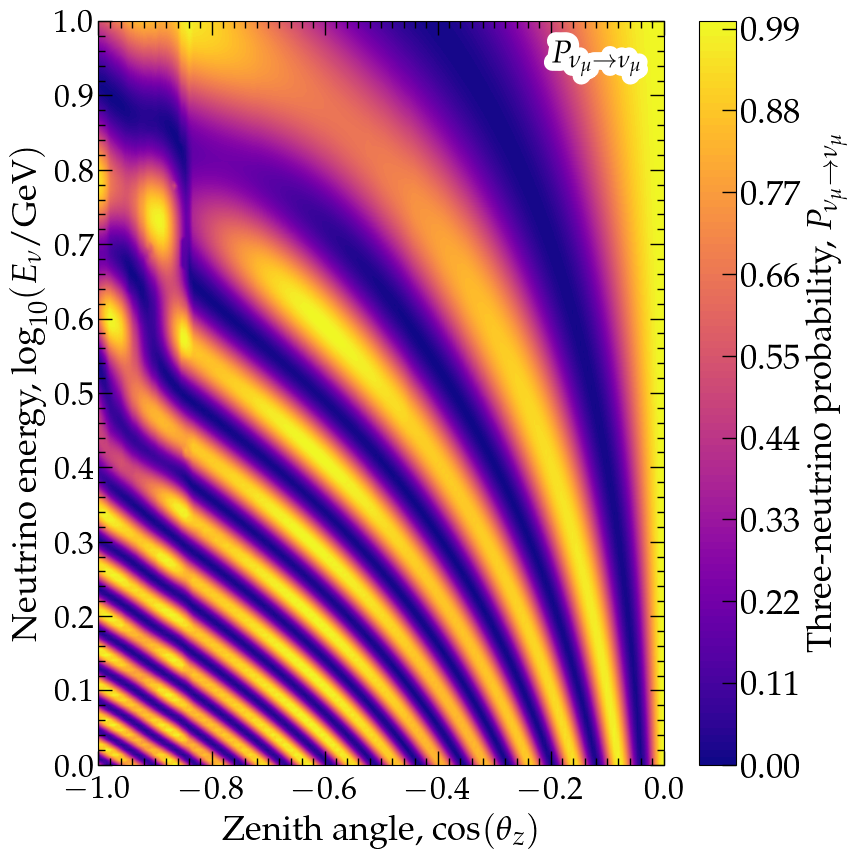

In [11]:
prob_arr_3nu_order_1 = make_oscillogram_plot(gd.NUMU, gd.NUMU, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                                             n_slabs=1, n_tpts_per_slab=100, magnus_exp_order=1, n_jobs=1,
                                             integration_method='trapezoid', validate_input=False,
                                             sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, 
                                             path=None, filename=None, format=None)

This already looks like it should, including showing the transition from core to mantle.  But the fine details are not quite there yet.  

Let's increase the number of slabs used to `n_slabs = 10` and use third-order Magnus expansion instead (`magnus_exp_order = 3`).  We can now set `n_jobs` to > 1 to compute evolution operators on each slab in parallel.

array([[0.49215266, 0.25395364, 0.07134706, ..., 0.74458645, 0.93140806,
        1.        ],
       [0.03642069, 0.00874718, 0.11024314, ..., 0.75163453, 0.93344766,
        1.        ],
       [0.15272589, 0.37534008, 0.6308581 , ..., 0.75851002, 0.93542804,
        1.        ],
       ...,
       [0.41934519, 0.43877189, 0.46534776, ..., 0.99701458, 0.99925308,
        1.        ],
       [0.47651876, 0.49607795, 0.52123457, ..., 0.99710535, 0.99927581,
        1.        ],
       [0.5329538 , 0.55283083, 0.57569901, ..., 0.99719337, 0.99929784,
        1.        ]])

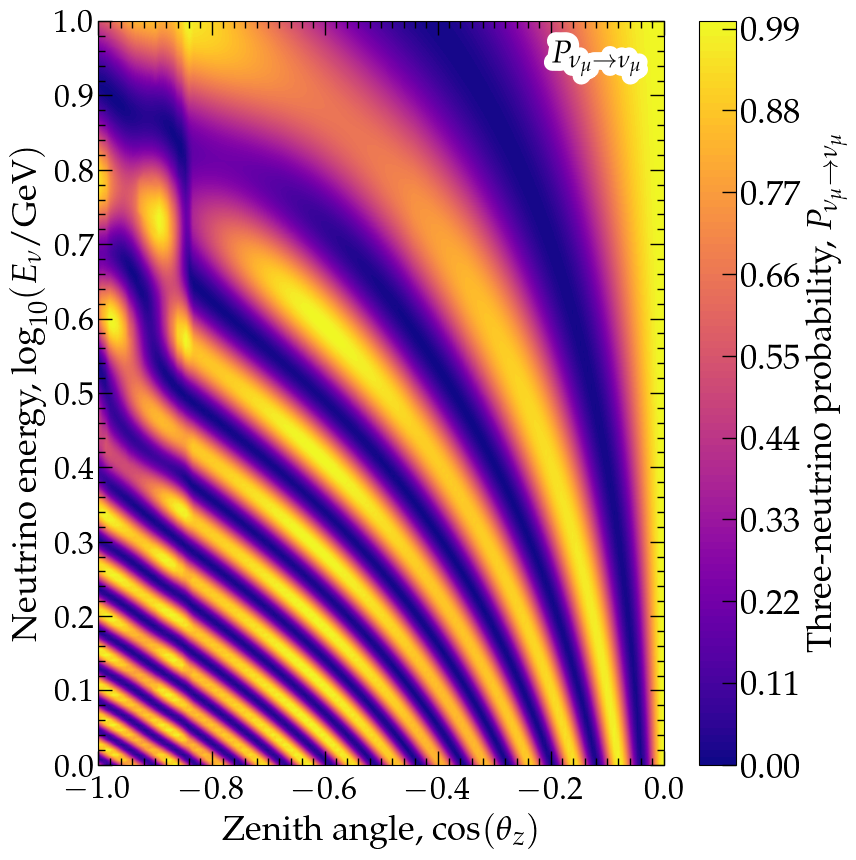

In [12]:
make_oscillogram_plot(gd.NUMU, gd.NUMU, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=10, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=5, integration_method='trapezoid', validate_input=False,
                      sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

If one would like to check whether this result is final or near-final, they can increase the `n_slabs` (or`n_tpts_per_slab`, or `magnus_exp_order`) and compare the resulting oscillogram with the one above.

We can also plot oscillograms for other probabilities:

array([[4.15530238e-01, 6.76858633e-01, 8.72650969e-01, ...,
        2.45522920e-01, 6.60605134e-02, 0.00000000e+00],
       [8.74184440e-01, 9.27288752e-01, 8.51126499e-01, ...,
        2.38762428e-01, 6.40977569e-02, 0.00000000e+00],
       [8.04573717e-01, 6.01647590e-01, 3.60024516e-01, ...,
        2.32166743e-01, 6.21919183e-02, 0.00000000e+00],
       ...,
       [4.81687918e-01, 4.73901265e-01, 4.59431320e-01, ...,
        2.87857747e-03, 7.20295354e-04, 0.00000000e+00],
       [4.27165647e-01, 4.16107317e-01, 4.03151976e-01, ...,
        2.79106734e-03, 6.98380361e-04, 0.00000000e+00],
       [3.73733455e-01, 3.60768640e-01, 3.48718722e-01, ...,
        2.70621486e-03, 6.77131952e-04, 0.00000000e+00]])

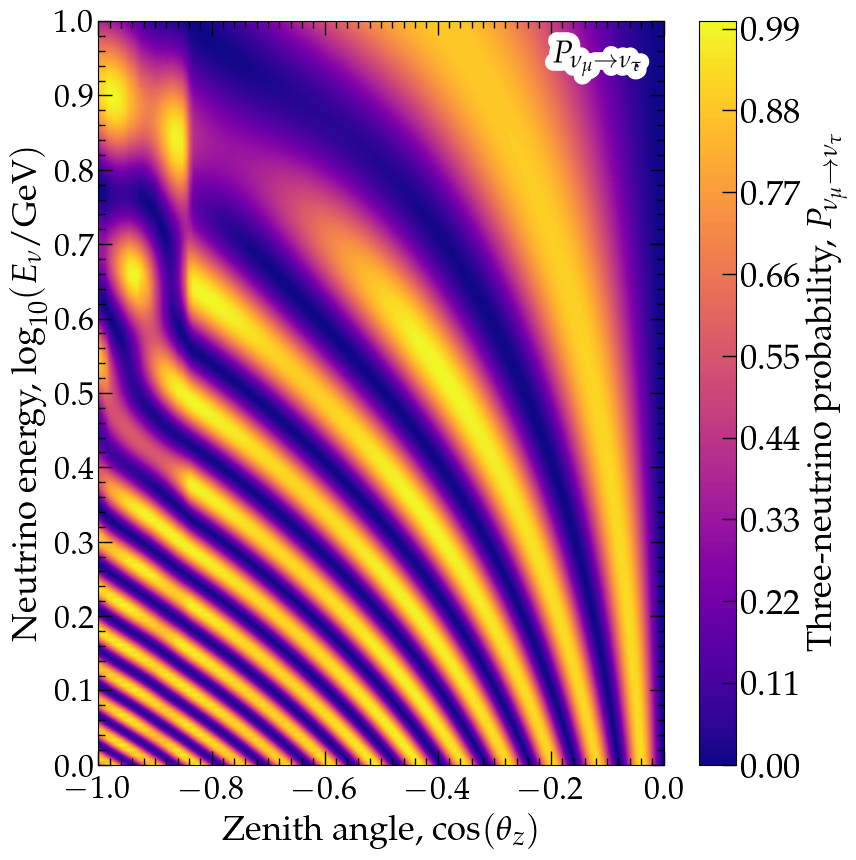

In [13]:
make_oscillogram_plot(gd.NUMU, gd.NUTAU, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=10, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=5, integration_method='trapezoid', validate_input=False,
                      sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

array([[9.23171058e-02, 6.91877276e-02, 5.60019670e-02, ...,
        9.89063380e-03, 2.53142402e-03, 0.00000000e+00],
       [8.93948659e-02, 6.39640664e-02, 3.86303610e-02, ...,
        9.60303746e-03, 2.45457920e-03, 0.00000000e+00],
       [4.27003943e-02, 2.30123287e-02, 9.11738818e-03, ...,
        9.32323215e-03, 2.38004169e-03, 0.00000000e+00],
       ...,
       [9.89668932e-02, 8.73268434e-02, 7.52209223e-02, ...,
        1.06839093e-04, 2.66242211e-05, 0.00000000e+00],
       [9.63155949e-02, 8.78147302e-02, 7.56134529e-02, ...,
        1.03578260e-04, 2.58126725e-05, 0.00000000e+00],
       [9.33127447e-02, 8.64005342e-02, 7.55822722e-02, ...,
        1.00417049e-04, 2.50258774e-05, 0.00000000e+00]])

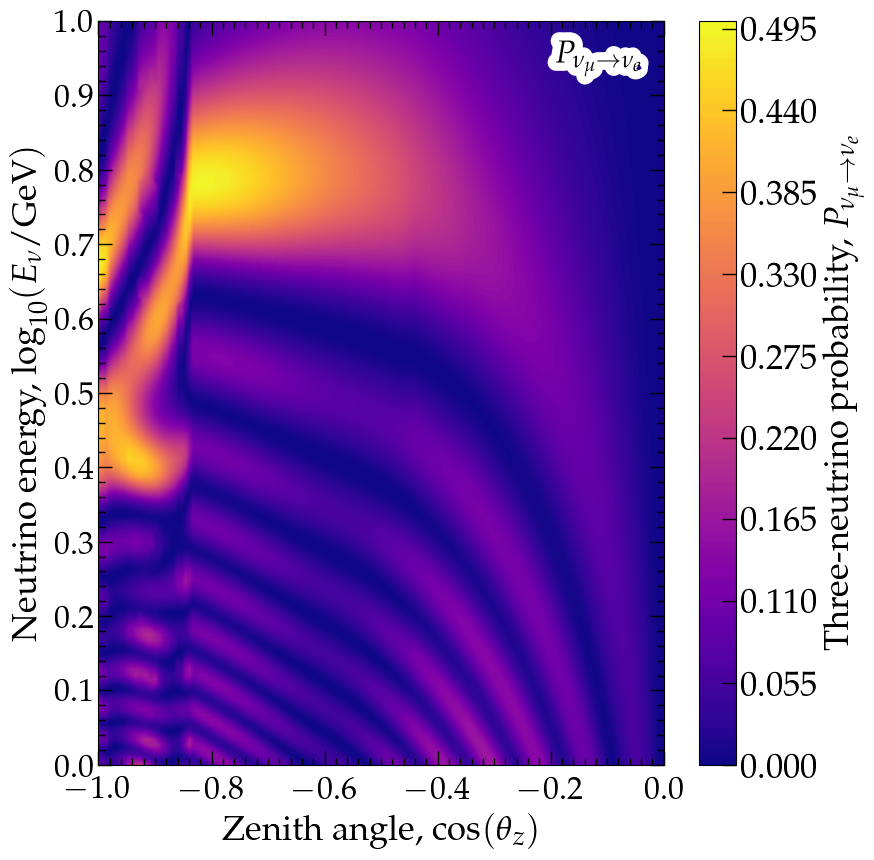

In [14]:
make_oscillogram_plot(gd.NUMU, gd.NUE, H_3nu_func_prem, costhz_arr, log10_Enu_arr,
                      n_slabs=10, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=5, integration_method='trapezoid', validate_input=False,
                      sector_2nu=None, cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

---

**Previous:** [Biprobability plots](05_magnus_biprobability.ipynb)  
**Next:** [BSM: sterile neutrinos](07_magnus_bsm_sterile_nu.ipynb) --- four and five flavours  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)